# Tier 1: scale, rotation and alignment over the alpha by weight-decay grid

**Hypothesis**

- **H0, the confound.** The usual kernel-movement statistic D does not identify the mechanism: cells with the same D can have the alignment climbing in one and flat in the other.
- **H1, a shared threshold.** Is the centred alignment at the moment of generalisation the same across alpha and decay? The kill criterion is a spread of more than a factor of two.
- **H2, scale given alignment.** Does the grokking time depend on the kernel scale once the alignment is known?

**Grid.** Width 100 in NTK parameterisation at base rate 100, alpha in 0.5, 1 and 2, eta times kappa in 0, 0.00001, 0.00003, 0.0001 and 0.0003. The proposal's decay values of 0.001 and above shrink the weights within a few thousand steps, so the axis was refined downwards. Runs are 100,000 steps; every saved seed is used where seeds matter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ntk_lib as L  # training loop, crossings, kernel terms and plot helpers shared by the tier notebooks

L.set_plot_style()

ALPHAS = [0.5, 1.0, 2.0]
DECAYS = [0.0, 1e-5, 3e-5, 1e-4, 3e-4]
SEEDS = [0, 1, 2, 3, 4]
STEPS = 100000

# Test accuracy at which the generalisation event is declared; the memorisation event is always train accuracy 1.
# Change this one number to move every crossing, table and figure in the notebook.
TEST_ACC_LEVEL = 1.0

def saved(alpha, ek, seed):
    """True if this seed of the cell is already trained and saved under results/."""
    return (L.RESULTS / (L.cell_name(100, alpha, ek, seed) + ".json")).exists()

# The main grid is seed 0 of every cell, trained if missing. Extra seeds are gathered where saved for the seed checks.
grid = {(a, ek): L.load_cell(100, a, ek, 0, STEPS, eval_interval=500) for a in ALPHAS for ek in DECAYS}
rows = {key: L.summarise_cell(run, test_level=TEST_ACC_LEVEL) for key, run in grid.items()}
extra = {(a, ek, s): L.load_cell(100, a, ek, s, STEPS, eval_interval=500)
         for a in ALPHAS for ek in DECAYS for s in SEEDS[1:] if saved(a, ek, s)}
extra_rows = {key: L.summarise_cell(run, test_level=TEST_ACC_LEVEL) for key, run in extra.items()}


## 1. The grid

One row per cell at seed 0. D is the movement statistic at the generalisation event, recovered from S and R through Equation 1 of the proposal. Kernel terms are blank when that event is censored.


In [2]:
# One line per cell: the two events, the grokking time, and the kernel terms read at the generalisation event.
print(f"{'alpha':>5} {'eta kappa':>9} {'t_train':>8} {'t_test':>8} {'t_grok':>8} {'A@test':>7} {'A peak':>7} {'S@test':>7} {'R@test':>7} {'D@test':>7}")
for (a, ek), r in rows.items():
    t_grok = L.fmt(r["t_grok"]) + ("+" if r["censored"] and r["t_grok"] is not None else "")  # plus marks a lower bound
    print(f"{a:>5g} {ek:>9g} {L.fmt(r['t_train']):>8} {L.fmt(r['t_test']):>8} {t_grok:>8} {L.fmt(r['A_at_test']):>7} "
          f"{L.fmt(r['A_peak']):>7} {L.fmt(r['S_at_test'], 2):>7} {L.fmt(r['R_at_test']):>7} {L.fmt(r['D_at_test'], 2):>7}")


alpha eta kappa  t_train   t_test   t_grok  A@test  A peak  S@test  R@test  D@test
  0.5         0     2000     5500     3500  0.1211  0.1238    2.03  0.0683    6.69
  0.5     1e-05     2000     5500     3500  0.1227  0.1250    2.00  0.0693    6.48
  0.5     3e-05     2000     6000     4000  0.1236  0.1261    1.99  0.0701    6.37
  0.5    0.0001     2000     4500     2500  0.1277  0.1501    1.81  0.0677    5.20
  0.5    0.0003     2000     3500     1500  0.1357  0.1588    1.46  0.0689    3.39
    1         0     4500    17000    12500  0.1163  0.1172    1.49  0.0631    3.53
    1     1e-05     4500    16000    11500  0.1184  0.1190    1.42  0.0636    3.21
    1     3e-05     4500    14500    10000  0.1214  0.1263    1.32  0.0640    2.82
    1    0.0001     4000    10000     6000  0.1274  0.1424    1.06  0.0631    1.98
    1    0.0003     4500     8500     4000  0.1368  0.1524    0.62  0.0676    0.99
    2         0     8500        -   91500+       -  0.1074       -       -       -
    

## 2. H0: the confound

Each cell as a path in the plane of movement D against alignment A, one panel per alpha and one colour per decay level; the large dots are generalisation events. If D identified the mechanism, cells at the same D would sit at the same A.

In [3]:
# One panel per alpha; each decay level is one path plus one dot at its generalisation event.
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, subplot_titles=[f"alpha {a:g}" for a in ALPHAS],
                    horizontal_spacing=0.04)
decay_colours = dict(zip(DECAYS, L.RAMP))
for col, a in enumerate(ALPHAS, start=1):
    for ek in DECAYS:
        run = grid[(a, ek)]
        h = run["history"]
        D = np.maximum([L.relative_movement(run, step) for step in h["step"]], 1e-3)
        fig.add_trace(go.Scatter(x=D, y=h["A_t"], mode="lines", line=dict(color=decay_colours[ek], width=1.8),
                                 name=f"eta kappa {ek:g}", legendgroup=str(ek), showlegend=(col == 1),
                                 customdata=h["step"],
                                 hovertemplate="step %{customdata}<br>D %{x:.3f}<br>A %{y:.4f}<extra>alpha " + f"{a:g}, eta kappa {ek:g}</extra>"),
                      row=1, col=col)
        t = rows[(a, ek)]["t_test"]
        if t is not None:
            fig.add_trace(go.Scatter(x=[max(L.relative_movement(run, t), 1e-3)], y=[L.value_at_step(run, "A_t", t)],
                                     mode="markers", marker=dict(color=decay_colours[ek], size=10, line=dict(color="white", width=1)),
                                     legendgroup=str(ek), showlegend=False,
                                     hovertemplate=f"generalisation event at step {t}<br>D %{{x:.3f}}<br>A %{{y:.4f}}<extra>alpha {a:g}, eta kappa {ek:g}</extra>"),
                          row=1, col=col)
    fig.update_xaxes(type="log", title_text="relative kernel movement D", row=1, col=col)
fig.update_yaxes(title_text="centred alignment A_t", row=1, col=1)
fig.update_layout(title="Cells with the same kernel movement reach different alignments; each cell is a path from initialisation",
                  height=450, width=1150, template="plotly_white", legend_title_text="line colour",
                  margin=dict(t=70, b=50))
fig.show()


## 3. Each cell as a path through scale, rotation and alignment

The three centred kernel terms as axes: scale, rotation and alignment. Every cell starts at zero scale and rotation with alignment near 0.09. Decay bends the paths towards smaller scale without lowering the alignment reached, and the generalisation dots of a panel cluster in rotation and alignment while spreading in scale.


In [4]:
# Three 3D scenes, one per alpha; each decay level is one path through (S, R, A) plus one dot at its generalisation event.
fig = make_subplots(rows=1, cols=3, specs=[[{"type": "scene"}] * 3], subplot_titles=[f"alpha {a:g}" for a in ALPHAS],
                    horizontal_spacing=0.02)
decay_colours = dict(zip(DECAYS, L.RAMP))
for col, a in enumerate(ALPHAS, start=1):
    for ek in DECAYS:
        run = grid[(a, ek)]
        h = run["history"]
        fig.add_trace(go.Scatter3d(x=h["S_c"], y=h["R_c"], z=h["A_t"], mode="lines", line=dict(color=decay_colours[ek], width=4),
                                   name=f"eta kappa {ek:g}", legendgroup=str(ek), showlegend=(col == 1), customdata=h["step"],
                                   hovertemplate="step %{customdata}<br>S %{x:.2f}<br>R %{y:.3f}<br>A %{z:.4f}<extra>alpha " + f"{a:g}, eta kappa {ek:g}</extra>"),
                      row=1, col=col)
        t = rows[(a, ek)]["t_test"]
        if t is not None:
            fig.add_trace(go.Scatter3d(x=[L.value_at_step(run, "S_c", t)], y=[L.value_at_step(run, "R_c", t)], z=[L.value_at_step(run, "A_t", t)],
                                       mode="markers", marker=dict(color=decay_colours[ek], size=5, line=dict(color="white", width=1)),
                                       legendgroup=str(ek), showlegend=False,
                                       hovertemplate=f"generalisation event at step {t}<br>S %{{x:.2f}}<br>R %{{y:.3f}}<br>A %{{z:.4f}}<extra>alpha {a:g}, eta kappa {ek:g}</extra>"),
                          row=1, col=col)
scene = dict(xaxis_title="scale S_t", yaxis_title="rotation R_t", zaxis_title="alignment A_t",
             camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9)))
fig.update_layout(scene=scene, scene2=scene, scene3=scene, height=520, width=1250, template="plotly_white",
                  title="Each cell as a path through scale, rotation and alignment; dots at the generalisation event",
                  legend_title_text="line colour", margin=dict(t=70, b=10, l=0, r=0))
fig.show()


## 4. The three pairs of terms, with a line through the generalisation events

The 3D paths above projected onto each pair of axes. Faint lines are the seed 0 paths of every cell and the points are the generalisation events of every saved seed, coloured by alpha with decay as shade. A dashed least-squares line is fitted through the events of each alpha, with its slope and correlation in the legend.


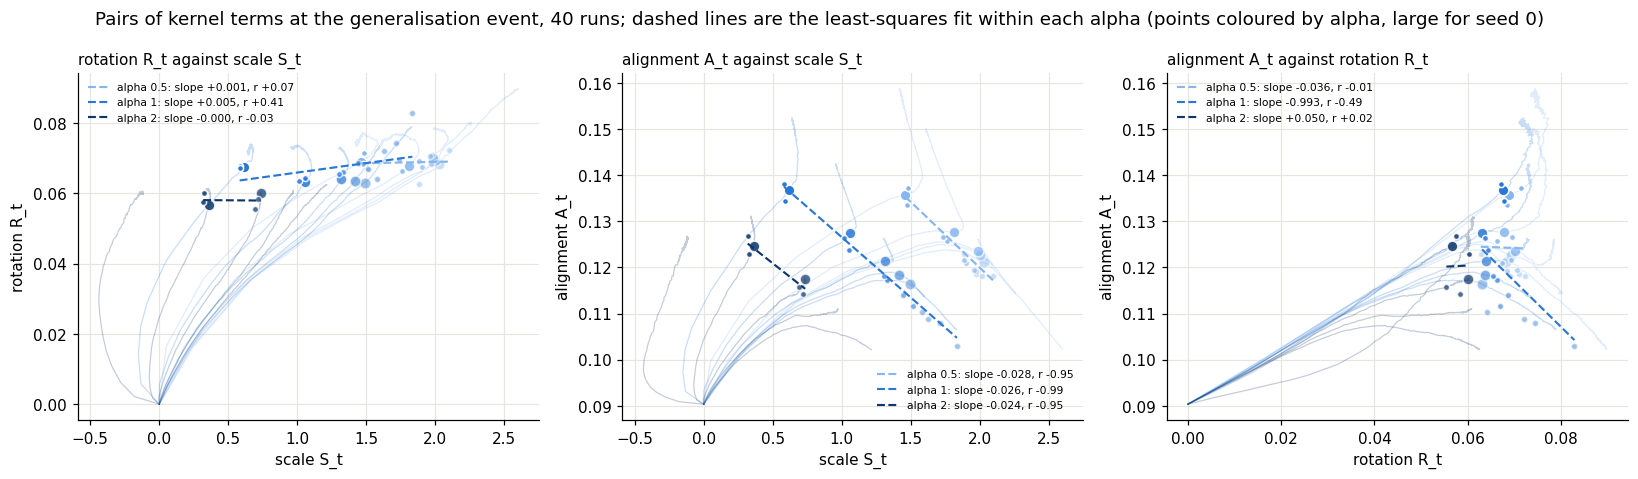

In [5]:
pairs = [("S_c", "R_c", "scale S_t", "rotation R_t"), ("S_c", "A_t", "scale S_t", "alignment A_t"), ("R_c", "A_t", "rotation R_t", "alignment A_t")]
alpha_colours = {0.5: L.RAMP[0], 1.0: L.RAMP[2], 2.0: L.RAMP[4]}
shade = dict(zip(DECAYS, np.linspace(0.45, 1.0, len(DECAYS))))  # lighter for no decay, full for the strongest

# Every saved run with a generalisation event: its three terms at that event.
events = []
for (a, ek), r in rows.items():
    if r["t_test"] is not None:
        events.append((a, ek, 0, r["S_at_test"], r["R_at_test"], r["A_at_test"]))
for (a, ek, s), r in extra_rows.items():
    if r["t_test"] is not None:
        events.append((a, ek, s, r["S_at_test"], r["R_at_test"], r["A_at_test"]))
col = {"S_c": 3, "R_c": 4, "A_t": 5}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (kx, ky, lx, ly) in zip(axes, pairs):
    for (a, ek), run in grid.items():  # faint paths, seed 0
        h = run["history"]
        ax.plot(h[kx], h[ky], color=alpha_colours[a], lw=0.8, alpha=0.25)
    x = np.array([e[col[kx]] for e in events]); y = np.array([e[col[ky]] for e in events])
    for e, xi, yi in zip(events, x, y):
        ax.plot([xi], [yi], "o", color=alpha_colours[e[0]], alpha=shade[e[1]], ms=7 if e[2] == 0 else 4, markeredgecolor="white", lw=0.5)
    # One least-squares line per alpha through that alpha's events.
    for a in ALPHAS:
        pick = np.array([e[0] == a for e in events])
        if pick.sum() < 3:
            continue
        sa, ia = np.polyfit(x[pick], y[pick], 1)
        ra = np.corrcoef(x[pick], y[pick])[0, 1]
        xa = np.linspace(x[pick].min(), x[pick].max(), 2)
        ax.plot(xa, sa * xa + ia, color=alpha_colours[a], lw=1.4, ls="--", label=f"alpha {a:g}: slope {sa:+.3f}, r {ra:+.2f}")
    ax.set_xlabel(lx); ax.set_ylabel(ly)
    ax.set_title(f"{ly} against {lx}", loc="left", fontsize=10)
    ax.legend(fontsize=7, loc="best")
    L.tidy_axes(ax)
fig.suptitle(f"Pairs of kernel terms at the generalisation event, {len(events)} runs; dashed lines are the least-squares fit within each alpha "
             "(points coloured by alpha, large for seed 0)")
fig.tight_layout()


## 5. H0 in two cells: equal movement, opposite mechanism

Alpha 1 with no decay grows its kernel and climbs in alignment. Alpha 1 with decay 0.001, the smallest value in the proposal's original grid, halves its weights within two thousand steps, shrinks its kernel, and leaves the alignment where it started. The two are compared at the bottom of the collapse and at the first step where the growing cell has the same movement. The four panels are the movement D and the three terms it is made of or read against: the scale term, the rotation term and the alignment.


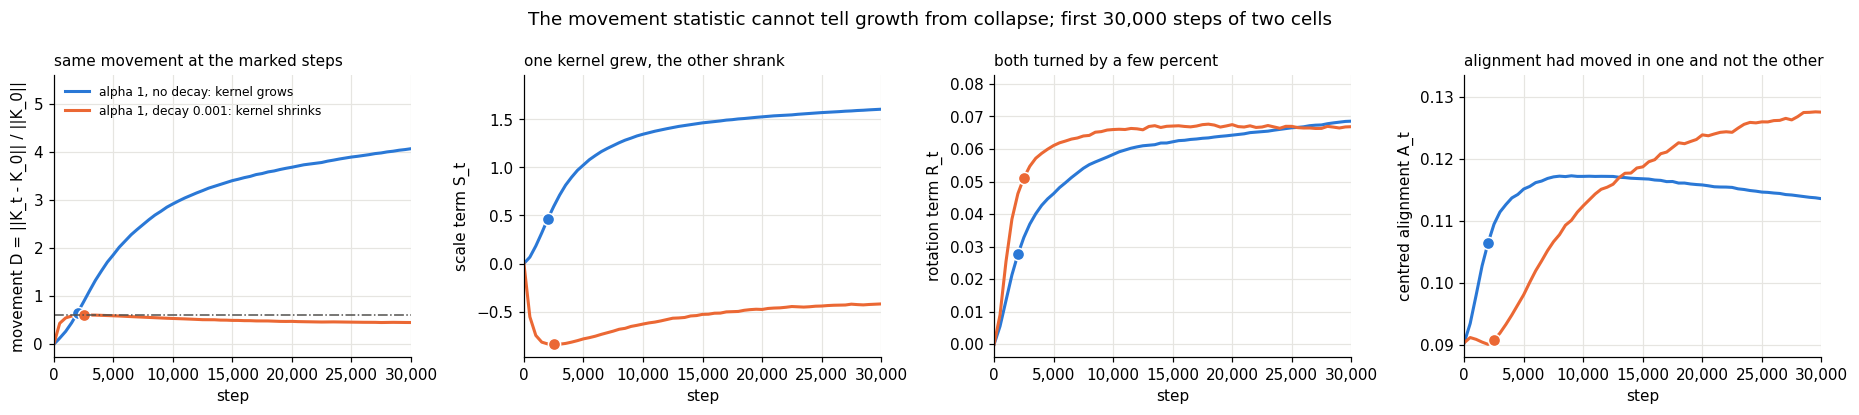

In [6]:
grow = grid[(1.0, 0.0)]  # the kernel grows and the network generalises
shrink = L.load_cell(100, 1.0, 1e-3, 0, STEPS, eval_interval=500)  # decay 0.001 collapses the weights

def path(run):
    """Steps, movement statistic, scale term, rotation term and alignment of one run at every checkpoint."""
    h = run["history"]
    return (np.asarray(h["step"]), np.array([L.relative_movement(run, t) for t in h["step"]]),
            np.asarray(h["S_c"]), np.asarray(h["R_c"]), np.asarray(h["A_t"]))

sg, Dg, Sg, Rg, Ag = path(grow)
ss, Ds, Ss, Rs, As = path(shrink)

# Take the shrinking cell at the bottom of its collapse, where its scale term is smallest, and the growing
# cell at the first checkpoint whose movement is at least as large. The two then have equal D.
j = int(np.argmin(Ss))
i = int(np.argmax(Dg >= Ds[j]))

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, (yg, ys), label in zip(axes, [(Dg, Ds), (Sg, Ss), (Rg, Rs), (Ag, As)],
                               ["movement D = ||K_t - K_0|| / ||K_0||", "scale term S_t", "rotation term R_t", "centred alignment A_t"]):
    ax.plot(sg, yg, color=L.BLUE, label="alpha 1, no decay: kernel grows")
    ax.plot(ss, ys, color=L.ORANGE, label="alpha 1, decay 0.001: kernel shrinks")
    ax.plot([sg[i]], [yg[i]], "o", color=L.BLUE, ms=8, markeredgecolor="white")
    ax.plot([ss[j]], [ys[j]], "o", color=L.ORANGE, ms=8, markeredgecolor="white")
    ax.set_xlabel("step"); ax.set_ylabel(label)
    ax.set_xlim(0, 30000)
    L.tidy_axes(ax)
axes[0].axhline(Ds[j], color=L.GRAY, lw=1, ls="-.")
axes[0].set_title("same movement at the marked steps", loc="left", fontsize=10)
axes[1].set_title("one kernel grew, the other shrank", loc="left", fontsize=10)
axes[2].set_title("both turned by a few percent", loc="left", fontsize=10)
axes[3].set_title("alignment had moved in one and not the other", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("The movement statistic cannot tell growth from collapse; first 30,000 steps of two cells")
fig.tight_layout()

## 6. A representative cell

Alpha 1 with no decay: the losses, the test accuracy, and the three kernel terms, with both events marked.


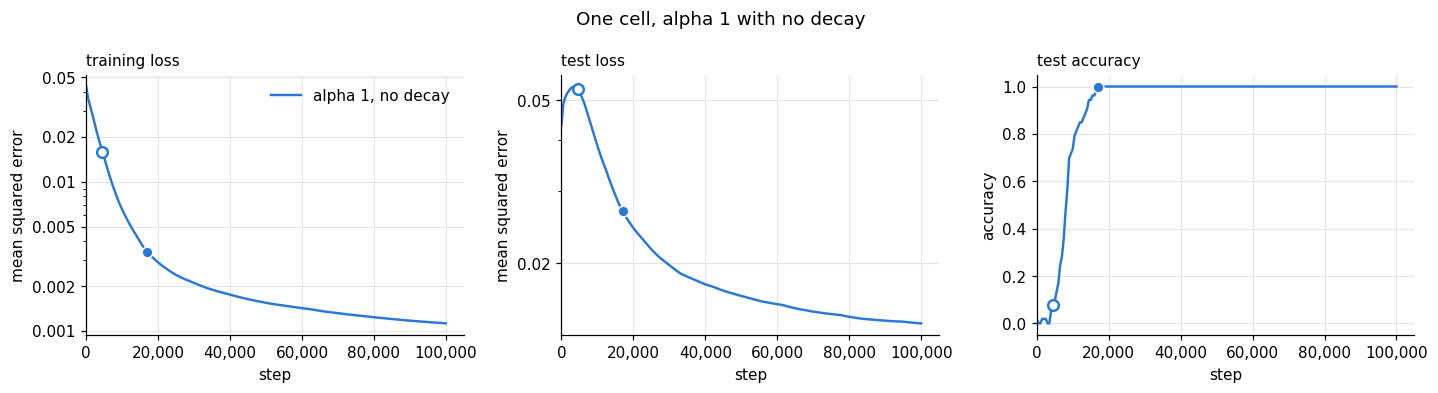

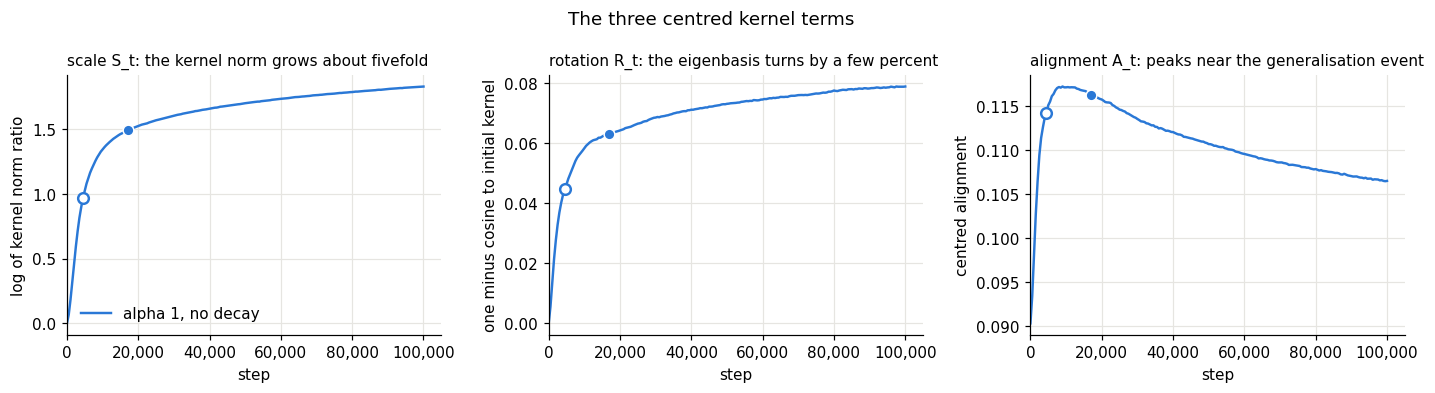

In [7]:
run = grid[(1.0, 0.0)]
g = L.accuracy_crossings(run, TEST_ACC_LEVEL)  # the two events, for the dots on every panel
fig = L.plot_series([run], ["train_loss", "test_loss", "test_acc"], ["alpha 1, no decay"], [L.BLUE],
                    ["training loss", "test loss", "test accuracy"], log_y=("train_loss", "test_loss"),
                    crossings=[g], log_x=False, mark_train=True,
                    suptitle="One cell, alpha 1 with no decay")
fig = L.plot_series([run], ["S_c", "R_c", "A_t"], ["alpha 1, no decay"], [L.BLUE],
                    ["scale S_t: the kernel norm grows about fivefold", "rotation R_t: the eigenbasis turns by a few percent",
                     "alignment A_t: peaks near the generalisation event"],
                    crossings=[g], log_x=False, mark_train=True,
                    suptitle="The three centred kernel terms")

## 7. Is that ordering of events shared across runs?

Two things stand out in the representative cell: the alignment peaks before the generalisation event, and the event comes just after the fast rise of the scale and rotation curves has flattened. This section checks both over every run with a generalisation event, seed 0 and the extra seeds.

Each panel puts the generalisation step along the bottom and one landmark of the run up the side, on log axes with the diagonal drawn; a point below the diagonal is a run where the landmark came before generalisation. The landmarks are the alignment peak, the step at which the alignment first reaches 95 percent of its peak, and the knees of the scale and rotation curves, taken as the step at which each first reaches 80 percent of its value at the end of the run. The peak itself is a poor landmark under decay, because the alignment keeps creeping up after generalisation and the peak lands at the end of the run; the 95 percent step is the fairer test of whether the alignment had essentially finished rising.


scale at the event: median 100% of its final value, range 74% to 117%
rotation at the event: median 92% of its final value, range 76% to 102%


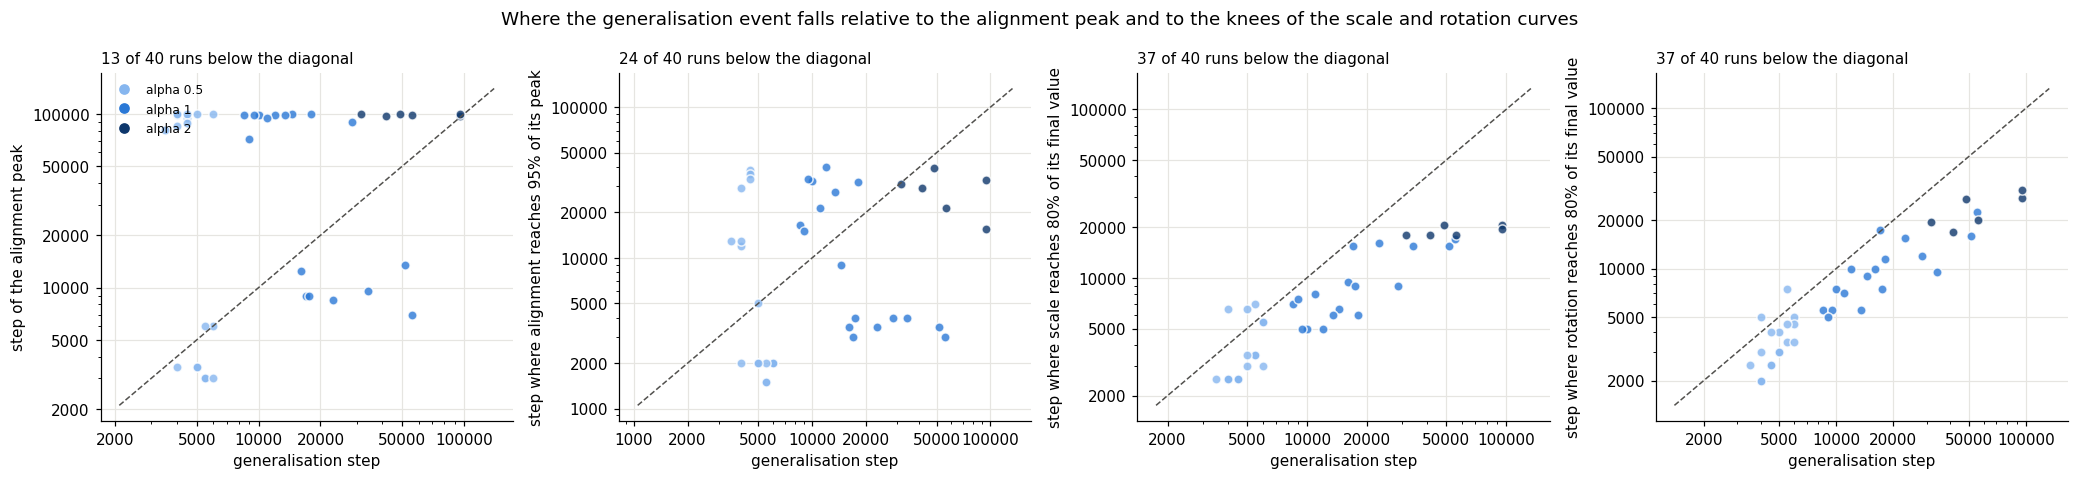

In [8]:
all_runs = {**{(a, ek, 0): run for (a, ek), run in grid.items()}, **extra}
all_rows = {**{(a, ek, 0): r for (a, ek), r in rows.items()}, **extra_rows}

def knee(run, key, fraction=0.8):
    """First step at which the recorded value reaches the given fraction of its value at the end of the run."""
    h = run["history"]
    return L.first_step_at_least(run, key, fraction * h[key][-1])

records = []
for k, r in all_rows.items():
    if r["t_test"] is None:
        continue
    run = all_runs[k]
    records.append(dict(alpha=k[0], t_test=r["t_test"], peak=L.peak_step(run, "A_t"),
                        kA=L.first_step_at_least(run, "A_t", 0.95 * r["A_peak"]),  # the alignment's own knee
                        A_ratio=r["A_at_test"] / r["A_peak"], kS=knee(run, "S_c"), kR=knee(run, "R_c"),
                        S_frac=r["S_at_test"] / run["history"]["S_c"][-1], R_frac=r["R_at_test"] / run["history"]["R_c"][-1]))

fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
for ax, key, label in [(axes[0], "peak", "step of the alignment peak"), (axes[1], "kA", "step where alignment reaches 95% of its peak"),
                       (axes[2], "kS", "step where scale reaches 80% of its final value"),
                       (axes[3], "kR", "step where rotation reaches 80% of its final value")]:
    for rec in records:
        ax.plot([rec["t_test"]], [rec[key]], "o", color=alpha_colours[rec["alpha"]], ms=6, alpha=0.8, markeredgecolor="white", lw=0.5)
    lo = min(min(rec["t_test"], rec[key]) for rec in records) * 0.7
    hi = max(max(rec["t_test"], rec[key]) for rec in records) * 1.4
    ax.plot([lo, hi], [lo, hi], color=L.GRAY, lw=1, ls="--")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("generalisation step"); ax.set_ylabel(label)
    below = sum(rec[key] < rec["t_test"] for rec in records)
    ax.set_title(f"{below} of {len(records)} runs below the diagonal", loc="left", fontsize=10)
    L.tidy_axes(ax)
for a in ALPHAS:
    axes[0].plot([], [], "o", color=alpha_colours[a], label=f"alpha {a:g}")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Where the generalisation event falls relative to the alignment peak and to the knees of the scale and rotation curves")
fig.tight_layout()

peak_ratio = np.array([rec["peak"] / rec["t_test"] for rec in records])
A_ratio = np.array([rec["A_ratio"] for rec in records])
for key, name in [("S_frac", "scale"), ("R_frac", "rotation")]:
    v = np.array([rec[key] for rec in records])
    print(f"{name} at the event: median {np.median(v):.0%} of its final value, range {v.min():.0%} to {v.max():.0%}")


The same test at several levels. Each row is one term and each column one level: the landmark is the first step at which the alignment reaches that share of its peak, or the scale and rotation reach that share of their value at the end of the run. The count in each title is the number of runs whose landmark came before the generalisation event.


/var/folders/w5/vtv9hx8d6h74_jxt4rl6czqh0000gn/T/ipykernel_27169/3883628219.py:22: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log"); ax.set_yscale("log")
/var/folders/w5/vtv9hx8d6h74_jxt4rl6czqh0000gn/T/ipykernel_27169/3883628219.py:31: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
/var/folders/w5/vtv9hx8d6h74_jxt4rl6czqh0000gn/T/ipykernel_27169/3883628219.py:31: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)


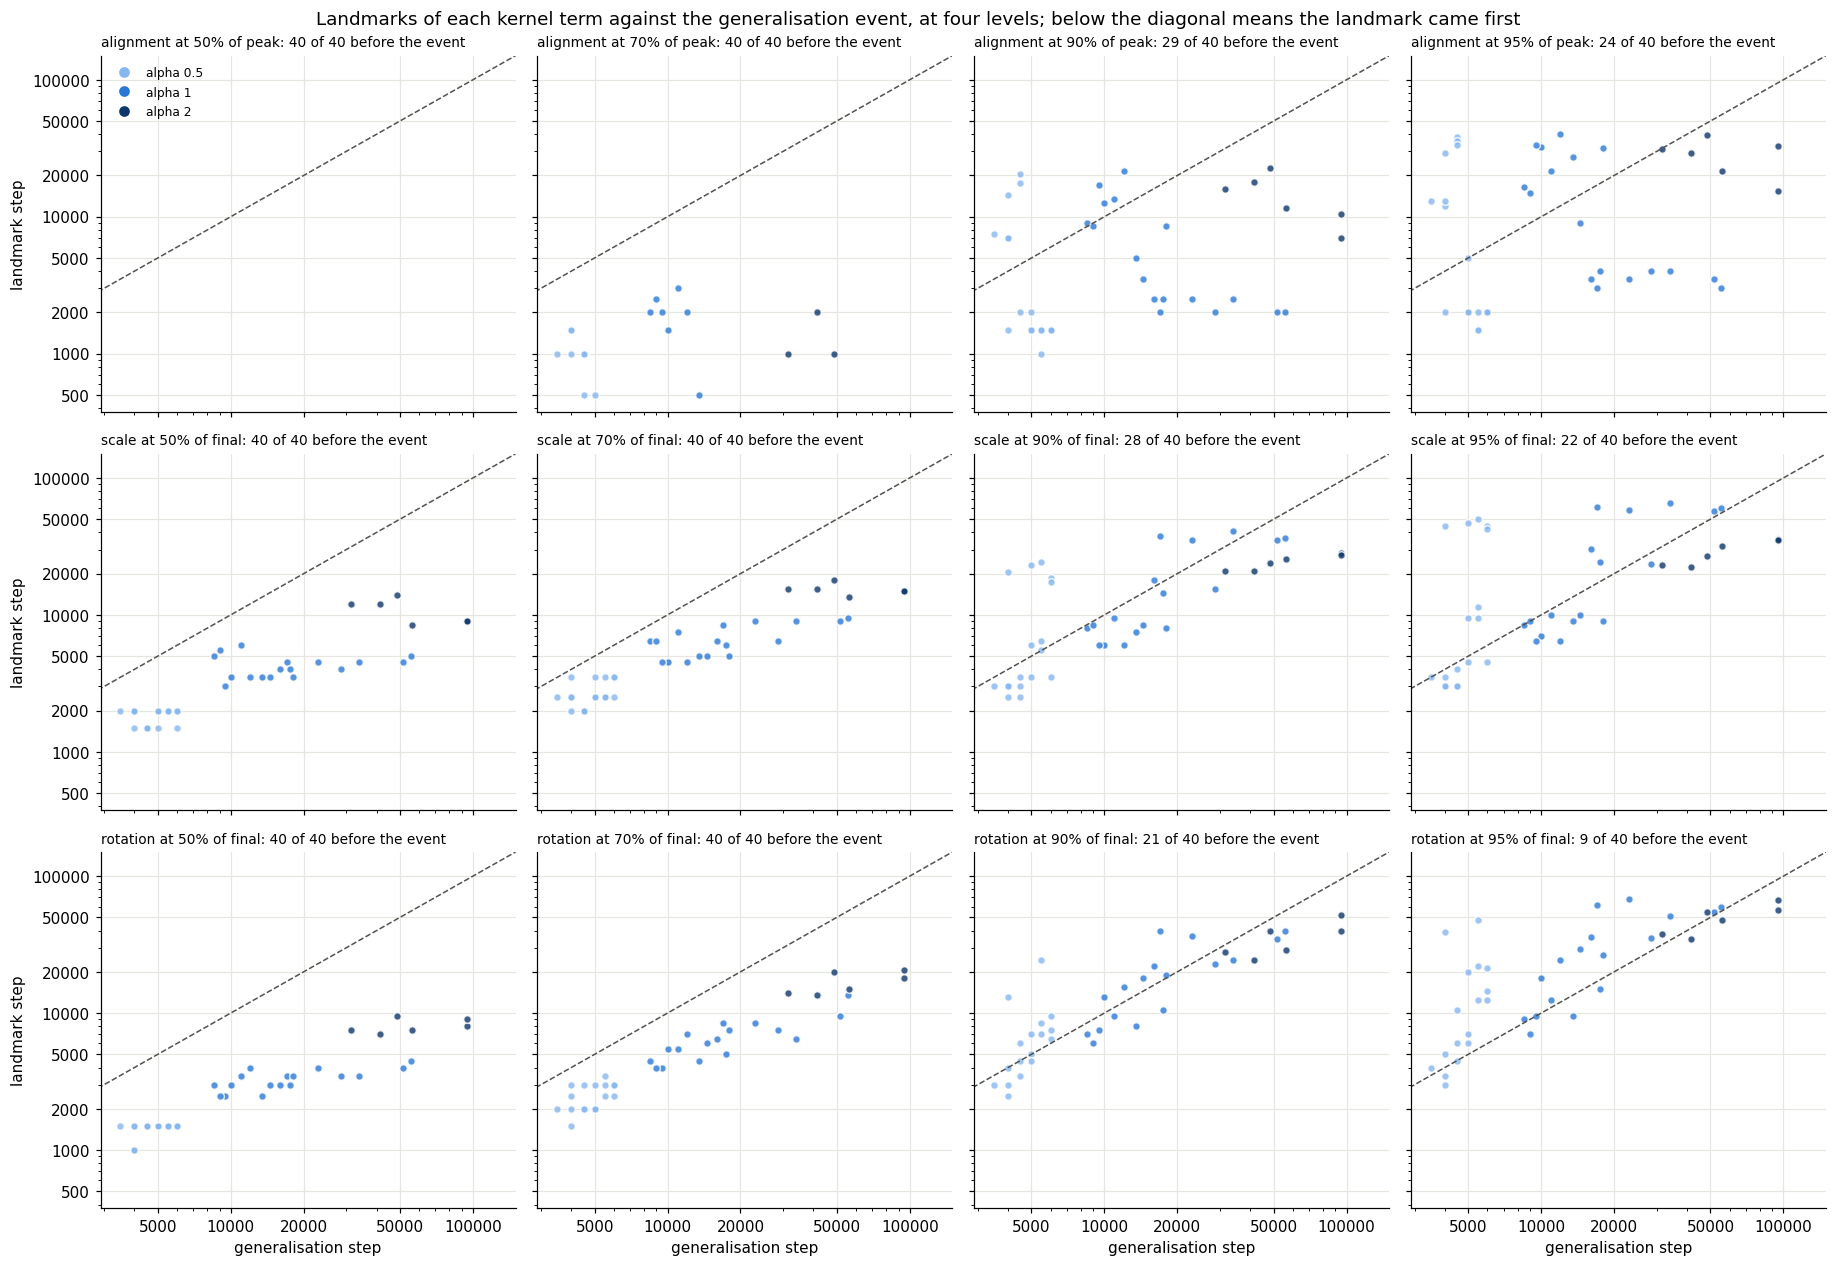

In [9]:
LEVELS = [0.5, 0.7, 0.9, 0.95]
terms = [("A_t", "alignment", "peak"), ("S_c", "scale", "final"), ("R_c", "rotation", "final")]
keys_with_event = [k for k, r in all_rows.items() if r["t_test"] is not None]
all_pts = []  # every landmark step drawn, to set one axis range for the whole grid

fig, axes = plt.subplots(len(terms), len(LEVELS), figsize=(4.2 * len(LEVELS), 3.9 * len(terms)), sharex=True, sharey=True)
for row, (key, name, ref) in enumerate(terms):
    for col, level in enumerate(LEVELS):
        ax = axes[row, col]
        pts = []
        for k in keys_with_event:
            run, r = all_runs[k], all_rows[k]
            target = level * (r["A_peak"] if ref == "peak" else run["history"][key][-1])
            landmark = L.first_step_at_least(run, key, target)
            if landmark is not None:
                pts.append((r["t_test"], landmark, k[0]))
        for t, s, a in pts:
            ax.plot([t], [s], "o", color=alpha_colours[a], ms=5, alpha=0.8, markeredgecolor="white", lw=0.5)
        all_pts.extend(s for t, s, a in pts)
        below = sum(s < t for t, s, a in pts)
        ax.set_title(f"{name} at {level:.0%} of {ref}: {below} of {len(pts)} before the event", loc="left", fontsize=9)
        ax.set_xscale("log"); ax.set_yscale("log")
        if row == len(terms) - 1:
            ax.set_xlabel("generalisation step")
        if col == 0:
            ax.set_ylabel("landmark step")
        L.tidy_axes(ax)
lo, hi = min(all_pts) * 0.7, 150000  # same range everywhere so the panels compare directly
for ax in axes.flat:
    ax.plot([lo, hi], [lo, hi], color=L.GRAY, lw=1, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
for a in ALPHAS:
    axes[0, 0].plot([], [], "o", color=alpha_colours[a], label=f"alpha {a:g}")
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Landmarks of each kernel term against the generalisation event, at four levels; below the diagonal means the landmark came first")
fig.tight_layout()


## 8. H1: is the alignment at the crossing shared across cells?

Hypothesis H1 says generalisation begins when the alignment crosses one threshold shared by every cell. Each panel shows one kernel term read at the generalisation event: every run is a point, grouped by alpha and coloured by decay, and the band is the mean and standard deviation over cells at seed 0. A flat band with points inside it is a shared threshold; the report's kill criterion is a max-to-min ratio above two. The kernel norm ratio is the contrast: it is the term that does not carry a threshold.


                     term at the event     mean      min      max  max/min  spread
                           alignment A   0.1244   0.1163   0.1368     1.18    5.3%
                            rotation R   0.0652   0.0567   0.0701     1.24    6.4%
              kernel norm ratio exp(S)   4.4414   1.4342   7.6099     5.31   49.9%

alignment spread across cells 0.0066, against 0.0022 between seeds of one cell (mean over 12 cells with several seeds)


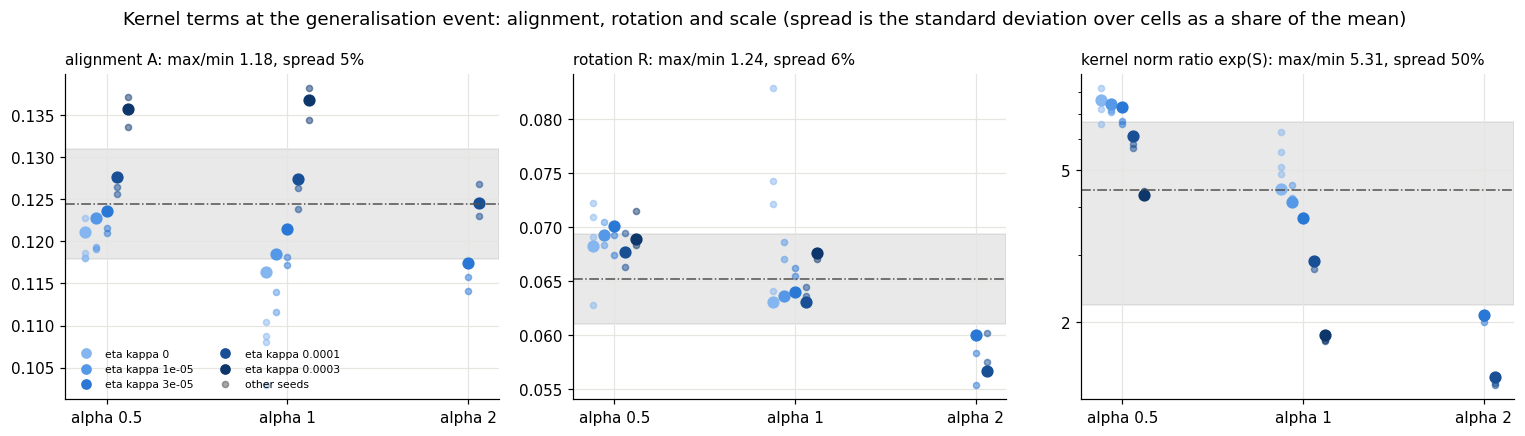

In [10]:
def at_event(key, transform=lambda x: x):
    """Value of one kernel term at the generalisation event for every run that has one, keyed by (alpha, decay, seed)."""
    vals = {(a, ek, 0): transform(r[key]) for (a, ek), r in rows.items() if r[key] is not None}
    vals.update({k: transform(r[key]) for k, r in extra_rows.items() if r[key] is not None})
    return vals

panels = [("A_at_test", "alignment A", lambda x: x),
          ("R_at_test", "rotation R", lambda x: x),
          ("S_at_test", "kernel norm ratio exp(S)", np.exp)]
decay_colours = dict(zip(DECAYS, L.RAMP))
offsets = dict(zip(DECAYS, np.linspace(-0.12, 0.12, len(DECAYS))))  # spread the decay levels within an alpha group
summary = []
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (key, label, transform) in zip(axes, panels):
    vals = at_event(key, transform)
    seed0 = np.array([v for (a, ek, s), v in vals.items() if s == 0])
    for (a, ek, s), v in vals.items():
        ax.plot([np.log2(a) + offsets[ek]], [v], "o", color=decay_colours[ek], ms=7 if s == 0 else 4, alpha=1 if s == 0 else 0.5)
    ax.axhspan(seed0.mean() - seed0.std(ddof=1), seed0.mean() + seed0.std(ddof=1), color=L.GRAY, alpha=0.12)
    ax.axhline(seed0.mean(), color=L.GRAY, lw=1, ls="-.")
    ax.set_xticks([np.log2(a) for a in ALPHAS]); ax.set_xticklabels([f"alpha {a:g}" for a in ALPHAS])
    ratio, cv = seed0.max() / seed0.min(), seed0.std(ddof=1) / seed0.mean()
    ax.set_title(f"{label}: max/min {ratio:.2f}, spread {cv:.0%}", loc="left", fontsize=10)
    if key == "S_at_test":
        ax.set_yscale("log")
    L.tidy_axes(ax)
    summary.append((label, seed0.mean(), seed0.min(), seed0.max(), ratio, cv))
for ek in DECAYS:
    axes[0].plot([], [], "o", color=decay_colours[ek], label=f"eta kappa {ek:g}")
axes[0].plot([], [], "o", color=L.GRAY, ms=4, alpha=0.5, label="other seeds")
axes[0].legend(fontsize=7, loc="lower left", ncol=2)
fig.suptitle("Kernel terms at the generalisation event: alignment, rotation and scale (spread is the standard deviation over cells as a share of the mean)")
fig.tight_layout()

A_star = np.array([v for (a, ek, s), v in at_event("A_at_test").items() if s == 0])  # used by the H2 section
within = [np.std([v for (a2, e2, s), v in at_event("A_at_test").items() if (a2, e2) == (a, ek)], ddof=1)
          for (a, ek) in rows if sum((a2, e2) == (a, ek) for (a2, e2, s) in at_event("A_at_test")) > 1]
print(f"{'term at the event':>38} {'mean':>8} {'min':>8} {'max':>8} {'max/min':>8} {'spread':>7}")
for label, m, lo, hi, ratio, cv in summary:
    print(f"{label:>38} {m:>8.4f} {lo:>8.4f} {hi:>8.4f} {ratio:>8.2f} {cv:>7.1%}")
print(f"\nalignment spread across cells {A_star.std(ddof=1):.4f}, against {np.mean(within):.4f} between seeds of one cell "
      f"(mean over {len(within)} cells with several seeds)")


## 9. H2: does scale matter once alignment is known?

**The question.** Hypothesis H2 says alignment is the whole clock: once you know how far a run's alignment has come, the size of its kernel tells you nothing more about when it will generalise. This section asks whether that is true.

**The idea.** For every run that generalised, record two things: how long its alignment took to reach a fixed level, the mean alignment at the event from Section 8, and how big its kernel was when it generalised, the scale term at the event. Then ask which of the two predicts the grokking time. If H2 is right, the alignment time predicts it and the kernel size adds nothing.

**The panels.** Left: grokking time against alignment time, each run coloured by its kernel size. Middle: does alignment time still predict the grokking time once kernel size is accounted for? Right: does kernel size still predict it once alignment time is accounted for? In the middle and right panels both axes have had the other variable removed, so a tilted cloud means yes and a flat cloud means no; the number in the title is the tilt as a partial correlation, with a bootstrap interval over runs. H predicts a tilt in the middle and a flat cloud on the right.

**A caveat the left panel shows.** The runs with the largest kernels, the dark points, generalised at about 2,500 steps but reached the shared alignment level only after 50,000, because their own alignment at the event sits below that level. Their alignment time is therefore far too late, and much of the right-hand tilt comes from them. Using each run's own crossing value instead would be circular, so this test cannot settle H2 with one shared level on a grid whose threshold drifts with decay and alpha.


22 of 40 measured runs reach the alignment level 0.1244.


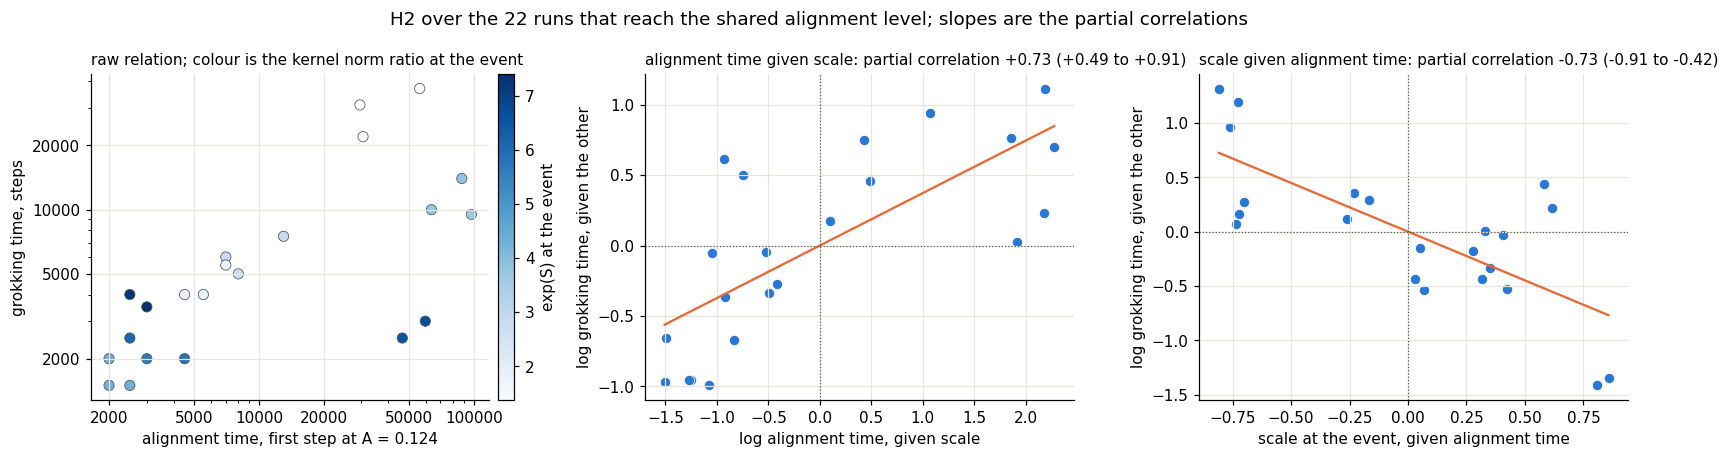

In [11]:
def residual(v, z):
    """The part of v not explained by z and an intercept."""
    Z = np.c_[np.ones(len(z)), z]
    return v - Z @ np.linalg.lstsq(Z, v, rcond=None)[0]

def partial_corr(y, x, z):
    """Correlation between y and x after regressing both on z and an intercept."""
    return np.corrcoef(residual(y, z), residual(x, z))[0, 1]

A_level = A_star.mean()
all_runs = {**{(a, ek, 0): run for (a, ek), run in grid.items()}, **extra}
all_rows = {**{(a, ek, 0): r for (a, ek), r in rows.items()}, **extra_rows}
# Keep runs with a measured grokking time whose alignment reaches the shared level at some step.
keys = [k for k, r in all_rows.items() if not r["censored"] and L.first_step_at_least(all_runs[k], "A_t", A_level) is not None]
y = np.log([all_rows[k]["t_grok"] for k in keys])
t_A = np.log([L.first_step_at_least(all_runs[k], "A_t", A_level) for k in keys])
S = np.array([all_rows[k]["S_at_test"] for k in keys])

rng = np.random.default_rng(0)
def interval(x, z):
    """Bootstrap interval over runs for the partial correlation of y with x given z."""
    boot = []
    for _ in range(2000):
        i = rng.integers(0, len(y), len(y))
        if np.std(x[i]) > 0 and np.std(z[i]) > 0:
            boot.append(partial_corr(y[i], x[i], z[i]))
    return np.percentile(boot, [2.5, 97.5])

pc_A, ci_A = partial_corr(y, t_A, S), interval(t_A, S)
pc_S, ci_S = partial_corr(y, S, t_A), interval(S, t_A)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
sc = ax.scatter(np.exp(t_A), np.exp(y), c=np.exp(S), cmap="Blues", s=45, edgecolor=L.GRAY, lw=0.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(f"alignment time, first step at A = {A_level:.3f}"); ax.set_ylabel("grokking time, steps")
ax.set_title("raw relation; colour is the kernel norm ratio at the event", loc="left", fontsize=10)
fig.colorbar(sc, ax=ax, fraction=0.05, pad=0.02).set_label("exp(S) at the event")
L.tidy_axes(ax)
for ax, x, z, pc, ci, xl, title in [
        (axes[1], t_A, S, pc_A, ci_A, "log alignment time, given scale", "alignment time given scale"),
        (axes[2], S, t_A, pc_S, ci_S, "scale at the event, given alignment time", "scale given alignment time")]:
    rx, ry = residual(x, z), residual(y, z)
    ax.scatter(rx, ry, s=45, color=L.BLUE, edgecolor="white", lw=0.5)
    slope = np.polyfit(rx, ry, 1)
    xs = np.linspace(rx.min(), rx.max(), 2)
    ax.plot(xs, np.polyval(slope, xs), color=L.ORANGE, lw=1.5)
    ax.axhline(0, color=L.GRAY, lw=0.8, ls=":"); ax.axvline(0, color=L.GRAY, lw=0.8, ls=":")
    ax.set_xlabel(xl); ax.set_ylabel("log grokking time, given the other")
    ax.set_title(f"{title}: partial correlation {pc:+.2f} ({ci[0]:+.2f} to {ci[1]:+.2f})", loc="left", fontsize=10)
fig.suptitle(f"H2 over the {len(y)} runs that reach the shared alignment level; slopes are the partial correlations")
fig.tight_layout()
print(f"{len(keys)} of {sum(not r['censored'] for r in all_rows.values())} measured runs reach the alignment level {A_level:.4f}.")
